# Supply Chain Analysis — Python & Pandas

**Dataset:** 100 SKUs | 3 Product Lines | 5 Suppliers  
**Tools:** Python, pandas, matplotlib  
**Goal:** Identify operational risks across product lines, suppliers, and logistics to support data-driven procurement decisions.

---

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/kaggle database.csv")
print(f"資料載入成功！共 {df.shape[0]} 筆資料，{df.shape[1]} 個欄位")

資料載入成功！共 100 筆資料，24 個欄位


## Analysis 1 — Revenue by Product Type

**Question:** Which product line generates the most revenue?  
**Why it matters:** Revenue distribution guides inventory prioritization and resource allocation.

Product type
skincare     241628.162133
haircare     174455.390606
cosmetics    161521.266001
Name: Revenue generated, dtype: float64


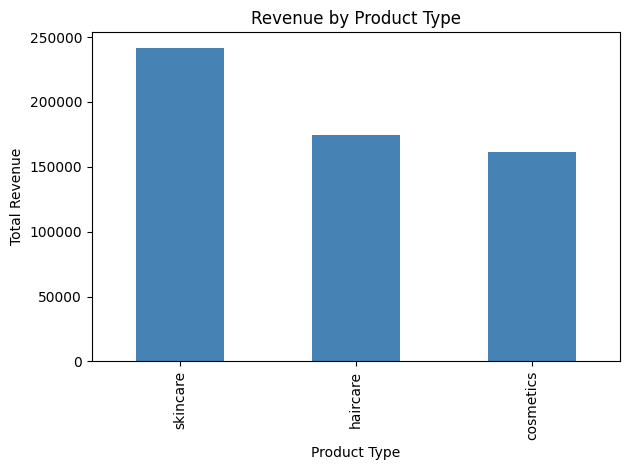

In [21]:
revenue_by_type = df.groupby('Product type')['Revenue generated'].sum().sort_values(ascending=False)
print(revenue_by_type)

revenue_by_type.plot(kind='bar', color='steelblue')
plt.title('Revenue by Product Type')
plt.ylabel('Total Revenue')
plt.xlabel('Product Type')
plt.tight_layout()
plt.show()

## Analysis 2 — Low Stock Warning

**Question:** Which products are at risk of stockout?  
**Why it matters:** Stockouts in high-revenue lines directly impact sales and customer satisfaction.

Low stock products: 27
   Product type    SKU  Stock levels
68     haircare  SKU68             0
2      haircare   SKU2             1
34     skincare  SKU34             1
16     skincare  SKU16             2
47     skincare  SKU47             4
33    cosmetics  SKU33             4
24     haircare  SKU24             4
8     cosmetics   SKU8             5
57     haircare  SKU57             5
87     haircare  SKU87             5
78     haircare  SKU78             5
4      skincare   SKU4             5
31     skincare  SKU31             6
15     skincare  SKU15             9
70     haircare  SKU70            10
18     haircare  SKU18            10
58     skincare  SKU58            10
6      skincare   SKU6            11
67     skincare  SKU67            12
44    cosmetics  SKU44            13
66     skincare  SKU66            13
9      skincare   SKU9            14
95     haircare  SKU95            15
85    cosmetics  SKU85            15
75     skincare  SKU75            16
73    cosmetics

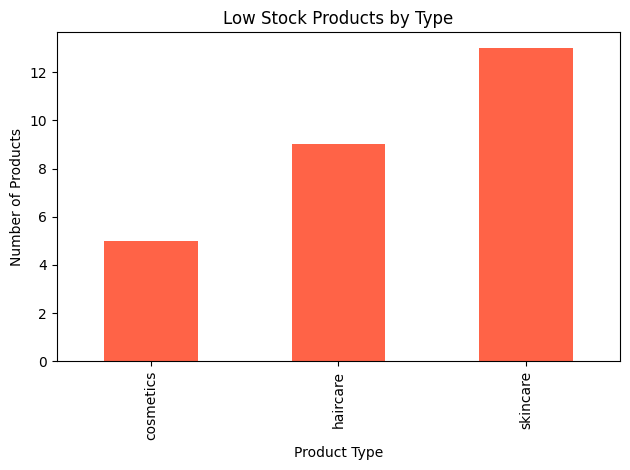

In [22]:
low_stock = df[df['Stock levels'] < 20]
print(f"Low stock products: {len(low_stock)}")
print(low_stock[['Product type', 'SKU', 'Stock levels']].sort_values('Stock levels'))

low_stock.groupby('Product type')['SKU'].count().plot(kind='bar', color='tomato')
plt.title('Low Stock Products by Type')
plt.ylabel('Number of Products')
plt.xlabel('Product Type')
plt.tight_layout()
plt.show()

## Analysis 3 — Defect Rate by Supplier

**Question:** Which supplier has the highest defect rate?  
**Why it matters:** High defect rates increase costs and signal quality control issues in the supply chain.

Supplier name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: Defect rates, dtype: float64


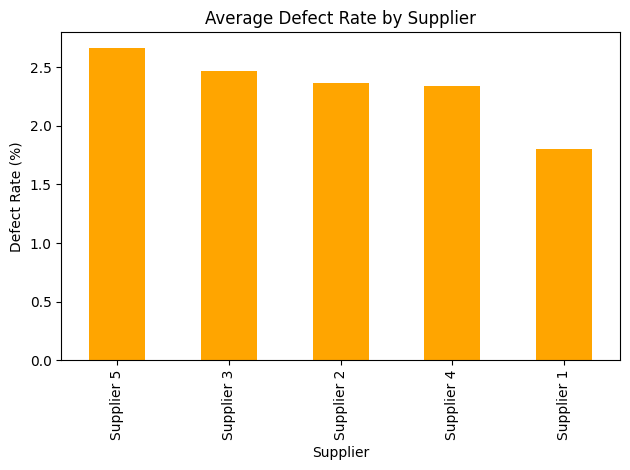

In [23]:
defect_by_supplier = df.groupby('Supplier name')['Defect rates'].mean().sort_values(ascending=False)
print(defect_by_supplier)

defect_by_supplier.plot(kind='bar', color='orange')
plt.title('Average Defect Rate by Supplier')
plt.ylabel('Defect Rate (%)')
plt.xlabel('Supplier')
plt.tight_layout()
plt.show()

## Analysis 4 — Cost by Transportation Mode

**Question:** Which transportation mode is most cost-efficient?  
**Why it matters:** Logistics cost directly affects margin. Identifying cheaper modes creates optimization opportunities.

Transportation modes
Air     561.712596
Road    553.385988
Rail    541.747556
Sea     417.819148
Name: Costs, dtype: float64


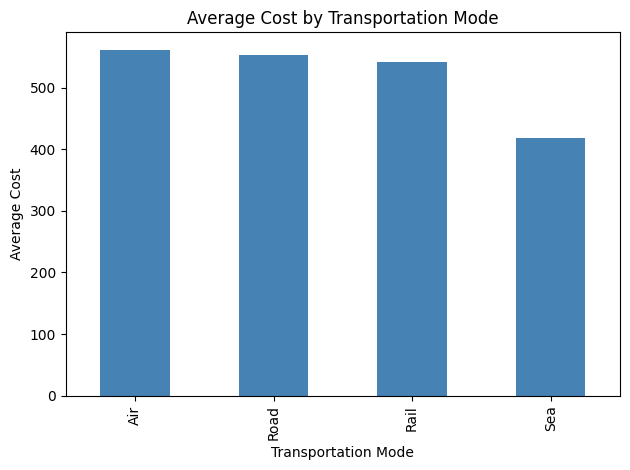

In [24]:
cost_by_transport = df.groupby('Transportation modes')['Costs'].mean().sort_values(ascending=False)
print(cost_by_transport)

cost_by_transport.plot(kind='bar', color='steelblue')
plt.title('Average Cost by Transportation Mode')
plt.ylabel('Average Cost')
plt.xlabel('Transportation Mode')
plt.tight_layout()
plt.show()

## Analysis 5 — Lead Time by Supplier

**Question:** Which supplier has the longest and most inconsistent lead time?  
**Why it matters:** Unpredictable lead times make inventory planning difficult and increase stockout risk.

               avg_lead  std_lead
Supplier name                    
Supplier 4         17.0       8.9
Supplier 1         16.8       8.6
Supplier 2         16.2       8.8
Supplier 5         14.7       9.6
Supplier 3         14.3       8.8


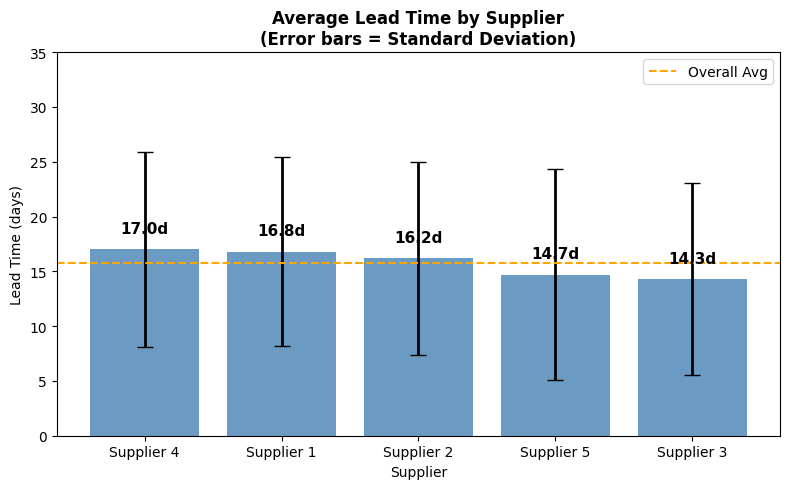

In [25]:
lead_by_supplier = df.groupby('Supplier name')['Lead times'].agg(
    avg_lead='mean', std_lead='std').round(1).sort_values('avg_lead', ascending=False)
print(lead_by_supplier)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(lead_by_supplier.index, lead_by_supplier['avg_lead'],
              color='steelblue', alpha=0.8,
              yerr=lead_by_supplier['std_lead'],
              capsize=6, error_kw={'color': 'tomato', 'linewidth': 2})
for bar, mean in zip(bars, lead_by_supplier['avg_lead']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{mean}d', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Average Lead Time by Supplier\n(Error bars = Standard Deviation)', fontweight='bold')
ax.set_xlabel('Supplier')
ax.set_ylabel('Lead Time (days)')
ax.set_ylim(0, 35)
ax.axhline(y=lead_by_supplier['avg_lead'].mean(), color='orange', linestyle='--', linewidth=1.5, label='Overall Avg')
ax.legend()
plt.tight_layout()
plt.show()

## Analysis 6 — Shipping Cost vs Revenue

**Question:** What percentage of revenue is consumed by shipping costs?  
**Why it matters:** High shipping cost ratios reduce margin and signal inefficient logistics spend.

              avg_shipping  avg_revenue  avg_ratio_pct
Product type                                          
cosmetics            6.060     6212.356            0.1
haircare             5.908     5131.041            0.2
skincare             4.910     6040.704            0.1


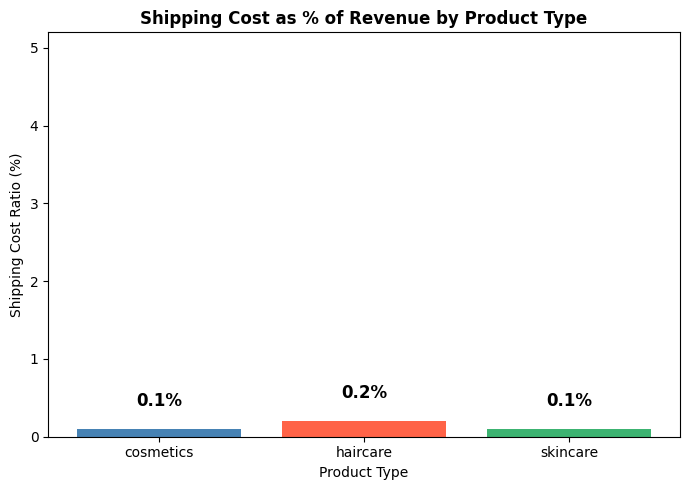

In [26]:
df['Shipping cost ratio'] = df['Shipping costs'] / df['Revenue generated']
shipping_ratio = df.groupby('Product type').agg(
    avg_shipping=('Shipping costs', 'mean'),
    avg_revenue=('Revenue generated', 'mean'),
    avg_ratio=('Shipping cost ratio', 'mean')).round(3)
shipping_ratio['avg_ratio_pct'] = (shipping_ratio['avg_ratio'] * 100).round(1)
print(shipping_ratio[['avg_shipping', 'avg_revenue', 'avg_ratio_pct']])

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(shipping_ratio.index, shipping_ratio['avg_ratio_pct'],
              color=['steelblue', 'tomato', 'mediumseagreen'])
for bar, val in zip(bars, shipping_ratio['avg_ratio_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Shipping Cost as % of Revenue by Product Type', fontweight='bold')
ax.set_ylabel('Shipping Cost Ratio (%)')
ax.set_xlabel('Product Type')
ax.set_ylim(0, shipping_ratio['avg_ratio_pct'].max() + 5)
plt.tight_layout()
plt.show()

## Analysis 7 — Inspection Results

**Question:** What is the distribution of Pass / Fail / Pending inspections? Which supplier has the most Fails?  
**Why it matters:** Fail rates directly impact product quality and downstream customer satisfaction. Identifying which suppliers drive failures enables targeted quality intervention.

=== Inspection Results ===
Inspection results
Pending    41
Fail       36
Pass       23
Name: count, dtype: int64

=== Fail by Supplier ===
Supplier name
Supplier 4    12
Supplier 2     8
Supplier 5     7
Supplier 1     6
Supplier 3     3
dtype: int64


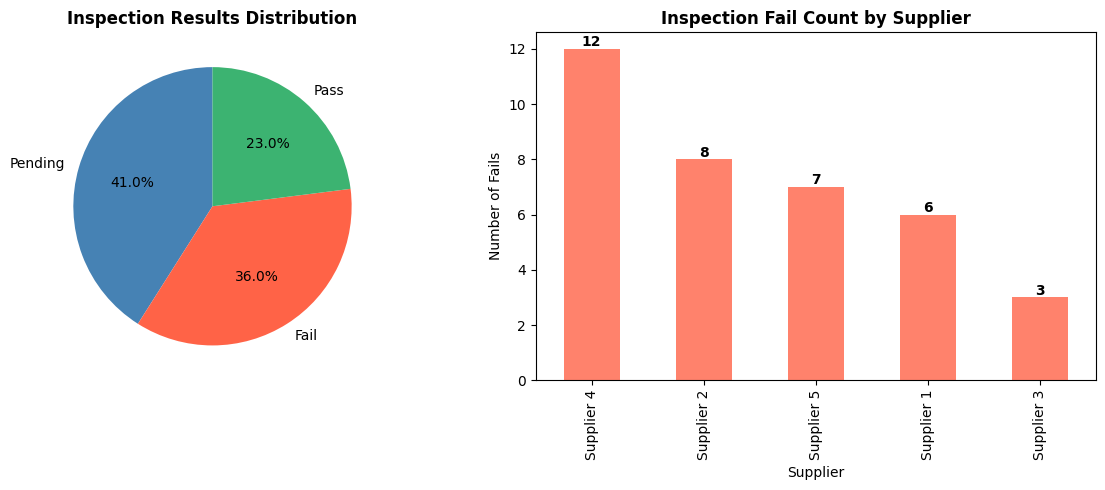

In [27]:
inspection_counts = df['Inspection results'].value_counts()
print("=== Inspection Results ===")
print(inspection_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {'Pass': 'mediumseagreen', 'Fail': 'tomato', 'Pending': 'steelblue'}
pie_colors = [colors[k] for k in inspection_counts.index]

axes[0].pie(inspection_counts, labels=inspection_counts.index,
            autopct='%1.1f%%', colors=pie_colors, startangle=90)
axes[0].set_title('Inspection Results Distribution', fontweight='bold')

fail_by_supplier = df[df['Inspection results'] == 'Fail'].groupby('Supplier name').size()
print("\n=== Fail by Supplier ===")
print(fail_by_supplier.sort_values(ascending=False))

fail_by_supplier.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='tomato', alpha=0.8)
axes[1].set_title('Inspection Fail Count by Supplier', fontweight='bold')
axes[1].set_xlabel('Supplier')
axes[1].set_ylabel('Number of Fails')

for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 int(bar.get_height()), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Analysis 8 — Order Distribution by Location

**Question:** Which cities generate the most orders?  
**Why it matters:** Geographic demand concentration informs regional inventory allocation and logistics planning.

=== Orders by Location ===
Location
Kolkata      25
Mumbai       22
Chennai      20
Bangalore    18
Delhi        15
dtype: int64


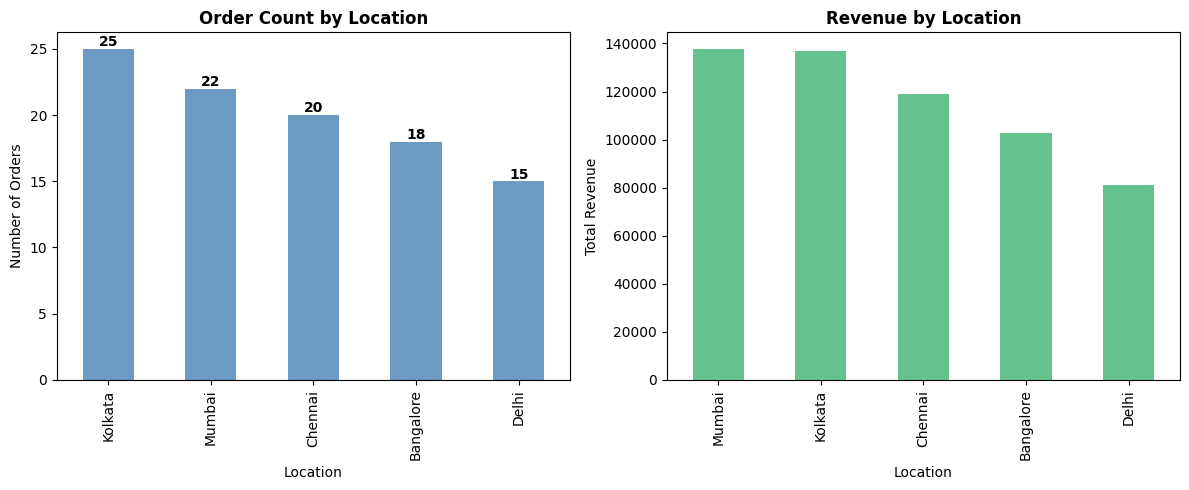

In [28]:
orders_by_location = df.groupby('Location').size().sort_values(ascending=False)
print("=== Orders by Location ===")
print(orders_by_location)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

orders_by_location.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Order Count by Location', fontweight='bold')
axes[0].set_xlabel('Location')
axes[0].set_ylabel('Number of Orders')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 int(bar.get_height()), ha='center', fontweight='bold')

revenue_by_location = df.groupby('Location')['Revenue generated'].sum().sort_values(ascending=False)
revenue_by_location.plot(kind='bar', ax=axes[1], color='mediumseagreen', alpha=0.8)
axes[1].set_title('Revenue by Location', fontweight='bold')
axes[1].set_xlabel('Location')
axes[1].set_ylabel('Total Revenue')

plt.tight_layout()
plt.show()

## Analysis 9 — Supplier Scorecard

**Question:** Which supplier performs best across lead time, defect rate, and inspection results combined?  
**Why it matters:** Procurement decisions rarely rely on a single metric. A composite scorecard provides a more complete and actionable view of supplier risk.

=== Supplier Risk Scorecard (Higher = More Risk) ===
               Avg Lead Time  Avg Defect Rate  Fail Count  Total Risk Score
Supplier name                                                              
Supplier 4             17.00             2.34          12              0.85
Supplier 2             16.23             2.36           8              0.66
Supplier 5             14.72             2.67           7              0.55
Supplier 1             16.78             1.80           6              0.43
Supplier 3             14.33             2.47           3              0.31


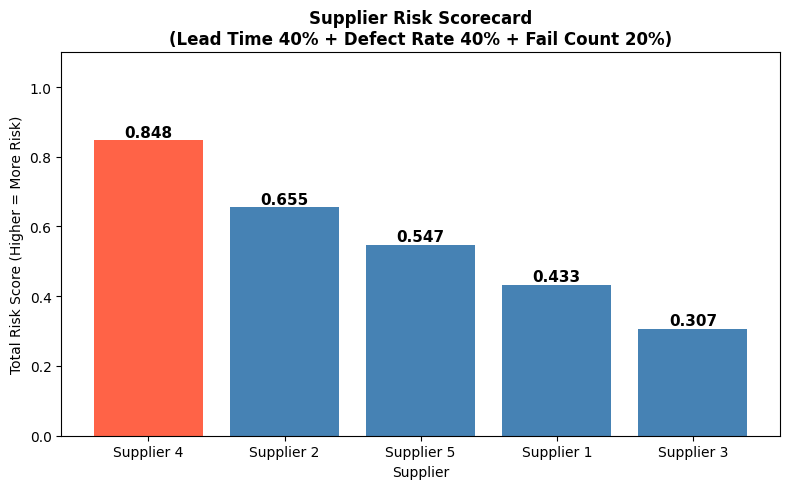

In [29]:
lead_avg = df.groupby('Supplier name')['Lead times'].mean()
defect_avg = df.groupby('Supplier name')['Defect rates'].mean()
fail_count = df[df['Inspection results'] == 'Fail'].groupby('Supplier name').size()

scorecard = pd.DataFrame({
    'Avg Lead Time': lead_avg,
    'Avg Defect Rate': defect_avg,
    'Fail Count': fail_count
}).fillna(0)

for col in scorecard.columns:
    scorecard[col + ' Score'] = (scorecard[col] - scorecard[col].min()) / (scorecard[col].max() - scorecard[col].min())

scorecard['Total Risk Score'] = (
    scorecard['Avg Lead Time Score'] * 0.4 +
    scorecard['Avg Defect Rate Score'] * 0.4 +
    scorecard['Fail Count Score'] * 0.2
).round(3)

result = scorecard[['Avg Lead Time', 'Avg Defect Rate', 'Fail Count', 'Total Risk Score']].sort_values('Total Risk Score', ascending=False)
print("=== Supplier Risk Scorecard (Higher = More Risk) ===")
print(result.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if s == result['Total Risk Score'].max() else 'steelblue' for s in result['Total Risk Score']]
bars = ax.bar(result.index, result['Total Risk Score'], color=colors)

for bar, val in zip(bars, result['Total Risk Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Supplier Risk Scorecard\n(Lead Time 40% + Defect Rate 40% + Fail Count 20%)', fontweight='bold')
ax.set_xlabel('Supplier')
ax.set_ylabel('Total Risk Score (Higher = More Risk)')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

### Scorecard Findings

| Supplier | Total Risk Score | Risk Level |
|----------|-----------------|------------|
| Supplier 4 | 0.848 | 🔴 High |
| Supplier 2 | 0.655 | 🟠 Medium-High |
| Supplier 5 | 0.547 | 🟡 Medium |
| Supplier 1 | 0.433 | 🟢 Low-Medium |
| Supplier 3 | 0.307 | 🟢 Low |

**Scoring methodology:** Lead Time (40%) + Defect Rate (40%) + Inspection Fail Count (20%)  
**Key insight:** Supplier 4 scores significantly higher than all others (0.848 vs 0.655), confirming it as the priority candidate for supplier review or renegotiation. Supplier 3 is the most reliable overall performer.

## Key Takeaways

- **Skincare** drives the highest revenue ($244K, 41% of total) but carries the greatest operational risk — 27% of SKUs are below safety stock and SKU68 is fully depleted
- **Supplier 4** is the highest-risk vendor across all dimensions — longest lead time (17 days), above-average defect rate, and highest inspection fail count — composite risk score of 0.848, significantly above the group average
- **Supplier 3** is the strongest performer with the lowest composite risk score (0.307) — recommended as preferred supplier for critical SKUs
- **Supplier 5** presents an independent quality risk with the highest defect rate (2.66%) — quality audit recommended regardless of lead time performance
- **Sea freight** is the most cost-efficient mode at ~25% below air freight — strategic shift toward sea routing could reduce logistics costs without compromising delivery windows
- Shipping costs remain below 0.2% of revenue across all product lines — logistics spend is well-controlled at current scale
- **Mumbai** generates the highest revenue despite fewer orders than Kolkata — indicating a higher average order value and stronger spending power per transaction
- A composite supplier scorecard integrating lead time, defect rate, and inspection results provides a more robust and actionable framework for procurement decisions than single-metric evaluation